# 09 — Phase 4-C: 공격 유형별 FAR 분석
> **목표:** 앙상블 모델의 공격 유형별 FAR/FRR 정량 분석 + Replay-Mask 혼동 심층 분석  
> **입력:** `stage2_best.h5` + `ensemble_meta.pkl` + CelebA-Spoof 어노테이션  
> **출력:** FAR 비교표 / Replay-Mask 혼동 분석 / Illumination별 FAR

## Cell 0. 환경 설정

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, pickle
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    classification_report
)

BASE        = '/content/drive/MyDrive/face-anti-spoofing'
MODEL_DIR   = f'{BASE}/models'
CROP_DIR    = f'{BASE}/data/cropped'
SUBSET_DIR  = f'{BASE}/data/subset'
REPORT_DIR  = f'{BASE}/reports/phase4'
ANNOT_PATH  = f'{BASE}/data/train_label.json'
os.makedirs(REPORT_DIR, exist_ok=True)

LABEL_MAP   = {'live': 0, 'print': 1, 'replay': 2, 'mask': 3}
LABEL_INV   = {v: k for k, v in LABEL_MAP.items()}
ILLUM_MAP   = {0: 'Indoor-normal', 1: 'Indoor-strong', 2: 'Outdoor-normal', 3: 'Outdoor-strong', 4: 'Outdoor-extreme'}
ENV_MAP     = {0: 'Indoor', 1: 'Outdoor'}

print('TF:', tf.__version__)
print('REPORT_DIR:', REPORT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF: 2.20.0
REPORT_DIR: /content/drive/MyDrive/face-anti-spoofing/reports/phase4


## Cell 1. 모델 로드

In [2]:
model = tf.keras.models.load_model(f'{MODEL_DIR}/stage2_best.h5')
print('✅ 모델 로드 완료')
model.summary(line_length=80)

✅ 모델 로드 완료


Model: "multitask_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1 (Conv2D)        │ (None, 112, 112,  │         864 │ input_layer[0][0]  │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn_Conv1              │ (None, 112, 112,  │         128 │ Conv1[0][0]        │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1_relu (ReLU)     │ (None, 112, 112,  │           0 │ bn_Conv1[0][0]     │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │         288 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │         128 │ expanded_conv_dep… │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │           0 │ expanded_conv_dep… │
│ (ReLU)                │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_project │ (None, 112, 112,  │         512 │ expanded_conv_dep… │
│ (Conv2D)              │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_projec… │ (None, 112, 112,  │          64 │ expanded_conv_pro… │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand        │ (None, 112, 112,  │       1,536 │ expanded_conv_pro… │
│ (Conv2D)              │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_BN     │ (None, 112, 112,  │         384 │ block_1_expand[0]… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_relu   │ (None, 112, 112,  │           0 │ block_1_expand_BN… │
│ (ReLU)                │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_pad           │ (None, 113, 113,  │           0 │ block_1_expand_re… │
│ (ZeroPadding2D)       │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise     │ (None, 56, 56,    │         864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)     │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_BN  │ (None, 56, 56,    │         384 │ block_1_depthwise… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_re… │ (None, 56, 56,    │           0 │ block_1_depthwise… │
│ (ReLU)                │ 96)  

 Total params: 2,624,263 (10.01 MB)

 Trainable params: 2,163,333 (8.25 MB)

 Non-trainable params: 460,928 (1.76 MB)

 Optimizer params: 2 (12.00 B)

## Cell 2. 테스트 데이터셋 구성 (어노테이션 포함)

In [7]:
# ── Cell 2. 테스트 데이터셋 구성 (어노테이션 포함) ──────────────

import json
import cv2
import numpy as np
from pathlib import Path

ANNOT_PATH  = f'{BASE}/data/train_label.json'
IMG_SIZE    = 224
MAX_PER_CAT = 500

LABEL_MAP = {'live': 0, 'print': 1, 'replay': 2, 'mask': 3}
LABEL_INV = {v: k for k, v in LABEL_MAP.items()}
ILLUM_MAP = {0: 'Indoor-normal', 1: 'Indoor-strong', 2: 'Outdoor-normal', 3: 'Outdoor-strong'}
ENV_MAP   = {0: 'Indoor', 1: 'Outdoor'}

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ── 어노테이션 로드 ───────────────────────────────────────────
print('어노테이션 로딩 중...')
try:
    with open(ANNOT_PATH, 'r') as f:
        raw_annot = json.load(f)
    fname2annot = {}
    for rel_path, attrs in raw_annot.items():
        fname = Path(rel_path).name
        if len(attrs) >= 43:
            fname2annot[fname] = {
                'spoof_type_annot': int(attrs[40]),
                'illumination':     int(attrs[41]),
                'environment':      int(attrs[42])
            }
    print(f'어노테이션 로드: {len(fname2annot):,}장')
except Exception as e:
    print(f'어노테이션 없음 ({e}) → illumination 분석 스킵')
    fname2annot = {}

# ── 이미지 로드 함수 ──────────────────────────────────────────
def load_imgs_with_meta(cat, max_per_cat=MAX_PER_CAT):
    folder    = Path(CROP_DIR) / cat
    all_paths = sorted(folder.glob('*.jpg'))
    paths     = all_paths[:max_per_cat]          # cap 고정
    n         = len(paths)
    n_train   = int(n * 0.7)
    n_val     = int(n * 0.15)
    test_paths = paths[n_train + n_val:]

    print(f'{cat:8s}: 전체 {len(all_paths)}장 → cap {n}장 → '
          f'train {n_train} / val {n_val} / test {len(test_paths)}')

    records = []
    for p in test_paths:
        img = cv2.imread(str(p))
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ImageNet 정규화 (학습과 동일)
        arr = (img.astype('float32') / 255.0 - IMAGENET_MEAN) / IMAGENET_STD

        meta = fname2annot.get(p.name, {})
        records.append({
            'path':         str(p),
            'fname':        p.name,
            'category':     cat,
            'spoof_label':  LABEL_MAP[cat],
            'binary_label': 0 if cat == 'live' else 1,
            'illumination': meta.get('illumination', -1),
            'environment':  meta.get('environment', -1),
            'img_arr':      arr
        })
    return records

# ── 전체 로드 ─────────────────────────────────────────────────
all_records = []
for cat in ['live', 'print', 'replay', 'mask']:
    recs = load_imgs_with_meta(cat, max_per_cat=MAX_PER_CAT)
    all_records.extend(recs)

print(f'\n총 test 샘플: {len(all_records)}장')
print('예상: 카테고리당 75장 × 4 = 300장')

어노테이션 로딩 중...
어노테이션 로드: 494,405장
live    : 전체 1500장 → cap 500장 → train 350 / val 75 / test 75
print   : 전체 1500장 → cap 500장 → train 350 / val 75 / test 75
replay  : 전체 1500장 → cap 500장 → train 350 / val 75 / test 75
mask    : 전체 1500장 → cap 500장 → train 350 / val 75 / test 75

총 test 샘플: 300장
예상: 카테고리당 75장 × 4 = 300장


## Cell 3. 모델 예측

In [8]:
X = np.stack([r['img_arr'] for r in all_records])

print('예측 중...')
preds = model.predict(X, batch_size=32, verbose=1)

# 모델 출력 파악 (binary_out, spoof_out)
# phase 4-B 앙상블과 동일한 단일 CNN 예측 기준으로 FAR 분석
if isinstance(preds, list):
    binary_prob = preds[0].flatten()   # sigmoid → P(FAKE)
    spoof_prob  = preds[1]             # softmax → [Live, Print, Replay, Mask]
else:
    # 단일 출력인 경우
    binary_prob = preds.flatten()
    spoof_prob  = None

binary_pred = (binary_prob >= 0.5).astype(int)
spoof_pred  = np.argmax(spoof_prob, axis=1) if spoof_prob is not None else None

# DataFrame 구성
df = pd.DataFrame(all_records).drop(columns=['img_arr'])
df['binary_prob']  = binary_prob
df['binary_pred']  = binary_pred
if spoof_pred is not None:
    df['spoof_pred'] = spoof_pred
    df['spoof_pred_name'] = df['spoof_pred'].map(LABEL_INV)

print('\n예측 완료')
print(df[['category', 'binary_label', 'binary_pred', 'binary_prob']].head(10))

예측 중...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

예측 완료
  category  binary_label  binary_pred   binary_prob
0     live             0            0  4.357257e-04
1     live             0            0  3.971866e-07
2     live             0            0  2.537694e-05
3     live             0            0  8.453693e-06
4     live             0            0  2.666679e-07
5     live             0            0  4.642409e-06
6     live             0            0  7.566422e-10
7     live             0            0  2.794562e-06
8     live             0            0  5.843032e-07
9     live             0            0  4.025088e-05


## Cell 4. 전체 Binary FAR / FRR

  Binary Accuracy : 0.9967 (99.67%)
  ROC-AUC         : 1.0000
  FAR (Spoof→Live): 0.0044 (0.44%)
  FRR (Live→Spoof): 0.0000 (0.00%)


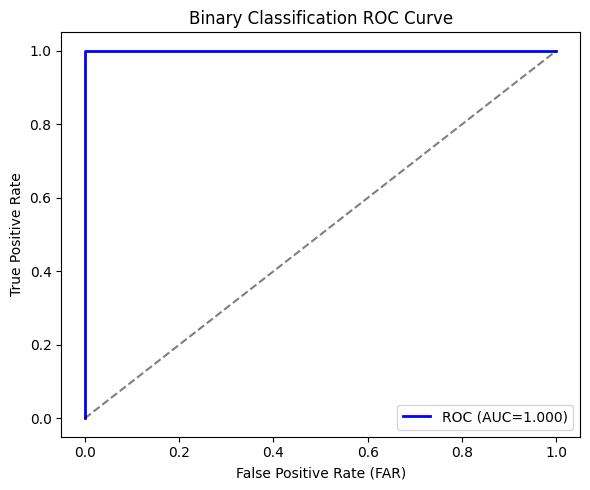

✅ ROC Curve 저장


In [9]:
y_true_bin = df['binary_label'].values
y_pred_bin = df['binary_pred'].values
y_prob_bin = df['binary_prob'].values

# FAR = Spoof → Live 오분류 / 전체 Spoof
spoof_mask = y_true_bin == 1
live_mask  = y_true_bin == 0

FAR_total = (y_pred_bin[spoof_mask] == 0).sum() / spoof_mask.sum()
FRR_total = (y_pred_bin[live_mask]  == 1).sum() / live_mask.sum()
ACC_total = (y_pred_bin == y_true_bin).mean()
AUC_total = roc_auc_score(y_true_bin, y_prob_bin)

print('='*55)
print(f'  Binary Accuracy : {ACC_total:.4f} ({ACC_total*100:.2f}%)')
print(f'  ROC-AUC         : {AUC_total:.4f}')
print(f'  FAR (Spoof→Live): {FAR_total:.4f} ({FAR_total*100:.2f}%)')
print(f'  FRR (Live→Spoof): {FRR_total:.4f} ({FRR_total*100:.2f}%)')
print('='*55)

# ROC Curve
fpr, tpr, _ = roc_curve(y_true_bin, y_prob_bin)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={AUC_total:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate')
plt.title('Binary Classification ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/roc_curve.png', dpi=150)
plt.show()
print(f'✅ ROC Curve 저장')

## Cell 5. 공격 유형별 FAR / FRR

In [10]:
# 각 공격 유형별로 FAR 계산
# FAR_attack = 해당 공격 유형 이미지 중 Live로 오분류된 비율

targets = ['print', 'replay', 'mask']
far_goals = {'print': 0.05, 'replay': 0.10, 'mask': 0.08}

far_results = []
for cat in targets:
    sub = df[df['category'] == cat]
    n   = len(sub)
    FAR = (sub['binary_pred'] == 0).sum() / n
    ACC = (sub['binary_pred'] == sub['binary_label']).mean()
    far_results.append({
        'Attack Type': cat.capitalize(),
        'N (test)':    n,
        'FAR':         FAR,
        'FAR (%)':     f'{FAR*100:.2f}%',
        'Target FAR':  f'< {far_goals[cat]*100:.0f}%',
        'Accuracy':    f'{ACC*100:.2f}%',
        'Pass':        '✅' if FAR < far_goals[cat] else '❌'
    })

# Live FRR도 포함
sub_live = df[df['category'] == 'live']
FRR_live = (sub_live['binary_pred'] == 1).sum() / len(sub_live)
far_results.append({
    'Attack Type': 'Live (FRR)',
    'N (test)':    len(sub_live),
    'FAR':         FRR_live,
    'FAR (%)':     f'{FRR_live*100:.2f}%',
    'Target FAR':  '< 15%',
    'Accuracy':    f'{(1-FRR_live)*100:.2f}%',
    'Pass':        '✅' if FRR_live < 0.15 else '❌'
})

far_df = pd.DataFrame(far_results)
print('\n공격 유형별 FAR 분석')
print(far_df[['Attack Type', 'N (test)', 'FAR (%)', 'Target FAR', 'Accuracy', 'Pass']].to_string(index=False))

far_df.to_csv(f'{REPORT_DIR}/far_by_attack.csv', index=False)
print(f'\n✅ FAR 비교표 저장: {REPORT_DIR}/far_by_attack.csv')


공격 유형별 FAR 분석
Attack Type  N (test) FAR (%) Target FAR Accuracy Pass
      Print        75   1.33%       < 5%   98.67%    ✅
     Replay        75   0.00%      < 10%  100.00%    ✅
       Mask        75   0.00%       < 8%  100.00%    ✅
 Live (FRR)        75   0.00%      < 15%  100.00%    ✅

✅ FAR 비교표 저장: /content/drive/MyDrive/face-anti-spoofing/reports/phase4/far_by_attack.csv


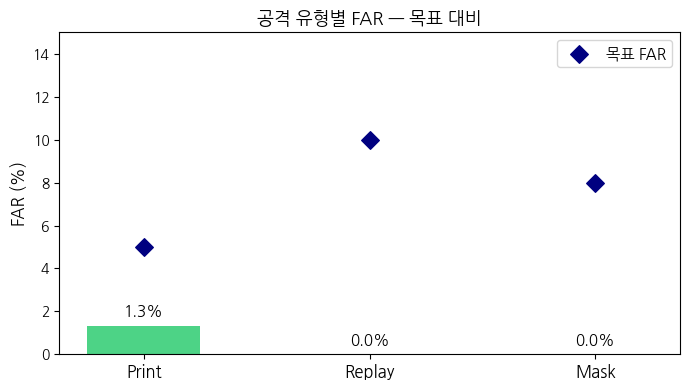

✅ FAR 바 차트 저장


In [13]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colab 한글 폰트 설치
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# FAR 바 차트
fig, ax = plt.subplots(figsize=(7, 4))

attack_names = ['Print', 'Replay', 'Mask']
far_vals  = [r['FAR'] for r in far_results[:3]]
goal_vals = [far_goals[c] for c in targets]
colors    = ['#e74c3c' if f >= g else '#2ecc71' for f, g in zip(far_vals, goal_vals)]

x = np.arange(len(attack_names))
bars = ax.bar(x, [v*100 for v in far_vals], color=colors, alpha=0.85, width=0.5)
ax.scatter(x, [v*100 for v in goal_vals], marker='D', color='navy', s=80,
           zorder=5, label='목표 FAR')

for bar, val in zip(bars, far_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(attack_names, fontsize=12)
ax.set_ylabel('FAR (%)', fontsize=12)
ax.set_title('공격 유형별 FAR — 목표 대비', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(far_vals)*100+5, max(goal_vals)*100+5))
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/far_by_attack.png', dpi=150)
plt.show()
print('✅ FAR 바 차트 저장')

## Cell 6. Spoof Type Confusion Matrix + Replay-Mask 혼동 정밀 분석

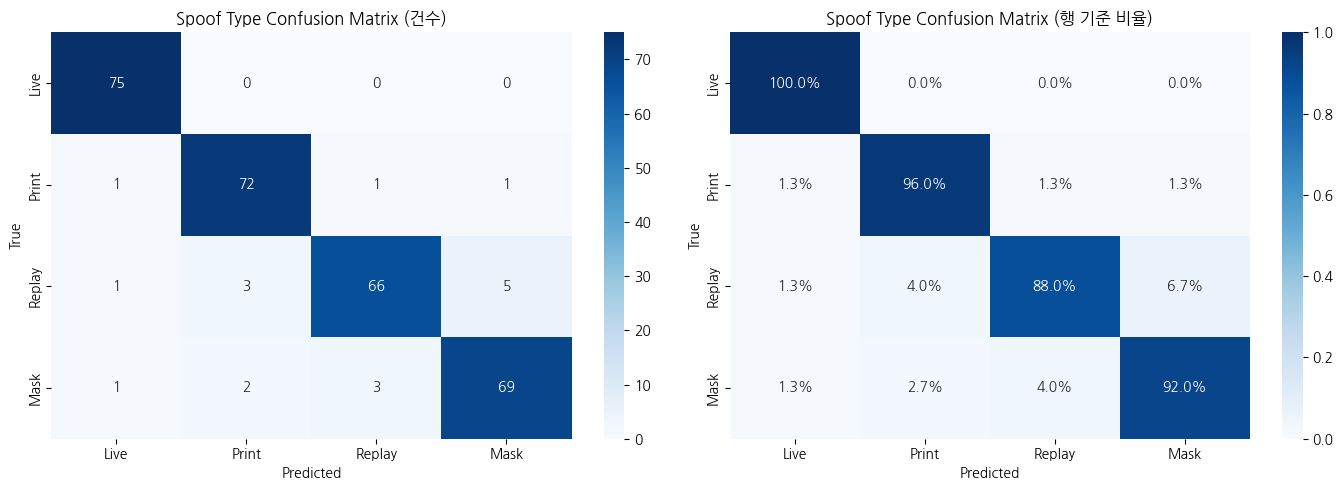


⚠️  Replay 오분류 분석
  Replay 전체: 75장
  → Replay 정답: 66건 (88.0%)
  → Replay → Mask 오분류: 5건 (6.7%)
  → Replay → Print 오분류: 3건 (4.0%)
  목표 (Replay-Mask 혼동 < 15%): ✅


In [14]:
if 'spoof_pred' in df.columns:
    y_spoof_true = df['spoof_label'].values
    y_spoof_pred = df['spoof_pred'].values

    cm = confusion_matrix(y_spoof_true, y_spoof_pred)
    labels = ['Live', 'Print', 'Replay', 'Mask']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 왼쪽: 절대값
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
                xticklabels=labels, yticklabels=labels, cmap='Blues')
    axes[0].set_title('Spoof Type Confusion Matrix (건수)')
    axes[0].set_ylabel('True')
    axes[0].set_xlabel('Predicted')

    # 오른쪽: 비율 (행 기준)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', ax=axes[1],
                xticklabels=labels, yticklabels=labels, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title('Spoof Type Confusion Matrix (행 기준 비율)')
    axes[1].set_ylabel('True')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/spoof_confusion_matrix.png', dpi=150)
    plt.show()

    # Replay-Mask 혼동 강조
    replay_idx = LABEL_MAP['replay']
    mask_idx   = LABEL_MAP['mask']
    replay_total   = (y_spoof_true == replay_idx).sum()
    replay2mask    = ((y_spoof_true == replay_idx) & (y_spoof_pred == mask_idx)).sum()
    replay2print   = ((y_spoof_true == replay_idx) & (y_spoof_pred == LABEL_MAP['print'])).sum()
    replay_correct = ((y_spoof_true == replay_idx) & (y_spoof_pred == replay_idx)).sum()

    print('\n⚠️  Replay 오분류 분석')
    print(f'  Replay 전체: {replay_total}장')
    print(f'  → Replay 정답: {replay_correct}건 ({replay_correct/replay_total*100:.1f}%)')
    print(f'  → Replay → Mask 오분류: {replay2mask}건 ({replay2mask/replay_total*100:.1f}%)')
    print(f'  → Replay → Print 오분류: {replay2print}건 ({replay2print/replay_total*100:.1f}%)')
    print(f'  목표 (Replay-Mask 혼동 < 15%): {"✅" if replay2mask/replay_total < 0.15 else "❌"}')
else:
    print('❌ spoof_pred 없음 — 모델 출력이 binary만 있음. Cell 3을 확인하세요.')

## Cell 7. Replay-Mask 혼동 케이스 — FFT/Laplacian 비교 (TS-06)

픽셀 수치 계산 중 (Replay 샘플)...

Replay → Mask 혼동: 5건
Replay 정답:        70건

          Laplacian 평균   FFT 고주파 에너지 평균
혼동 그룹:        291.3                 33709685
정답 그룹:        318.9                 30133825


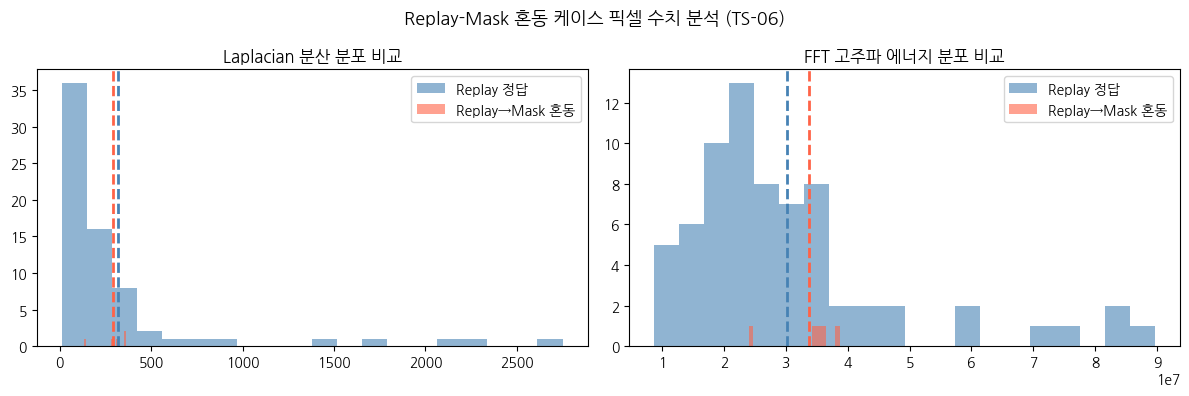

✅ Replay-Mask 픽셀 분석 저장


In [15]:
# Replay를 Mask로 오분류한 케이스 vs 정답 케이스 수치 비교
# → 블러 패턴 차이가 있는지 검증 (TS-06 핵심)

def compute_pixel_metrics(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None
    lap  = cv2.Laplacian(img, cv2.CV_64F).var()
    fft  = np.abs(np.fft.fft2(img))
    fft_shift = np.fft.fftshift(fft)
    h, w = img.shape
    cy, cx = h//2, w//2
    r = min(h, w) // 4
    mask_fft = np.zeros_like(fft_shift)
    cv2.circle(mask_fft, (cx, cy), r, 1, -1)
    high_energy = np.sum(fft_shift * (1 - mask_fft))
    return lap, high_energy

if 'spoof_pred' in df.columns:
    replay_df = df[df['category'] == 'replay'].copy()
    replay_df['confused'] = (replay_df['spoof_pred'] == LABEL_MAP['mask']).astype(int)

    print('픽셀 수치 계산 중 (Replay 샘플)...')
    laps, ffts = [], []
    for path in replay_df['path']:
        l, f = compute_pixel_metrics(path)
        laps.append(l)
        ffts.append(f)
    replay_df['laplacian'] = laps
    replay_df['fft_high']  = ffts

    # 혼동 그룹 vs 정답 그룹 비교
    confused_group = replay_df[replay_df['confused'] == 1]
    correct_group  = replay_df[replay_df['confused'] == 0]

    print(f'\nReplay → Mask 혼동: {len(confused_group)}건')
    print(f'Replay 정답:        {len(correct_group)}건')
    print()
    print(f'          Laplacian 평균   FFT 고주파 에너지 평균')
    print(f'혼동 그룹: {confused_group["laplacian"].mean():12.1f}   {confused_group["fft_high"].mean():22.0f}')
    print(f'정답 그룹: {correct_group["laplacian"].mean():12.1f}   {correct_group["fft_high"].mean():22.0f}')

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col, title in zip(axes, ['laplacian', 'fft_high'], ['Laplacian 분산', 'FFT 고주파 에너지']):
        data_c = confused_group[col].dropna()
        data_r = correct_group[col].dropna()
        ax.hist(data_r, bins=20, alpha=0.6, label='Replay 정답', color='steelblue')
        ax.hist(data_c, bins=20, alpha=0.6, label='Replay→Mask 혼동', color='tomato')
        ax.axvline(data_r.mean(), color='steelblue', lw=2, ls='--')
        ax.axvline(data_c.mean(), color='tomato',    lw=2, ls='--')
        ax.set_title(f'{title} 분포 비교')
        ax.legend()
    plt.suptitle('Replay-Mask 혼동 케이스 픽셀 수치 분석 (TS-06)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/replay_mask_confusion_pixel.png', dpi=150)
    plt.show()
    print('✅ Replay-Mask 픽셀 분석 저장')

## Cell 8. 혼동 케이스 시각화 (샘플 이미지)

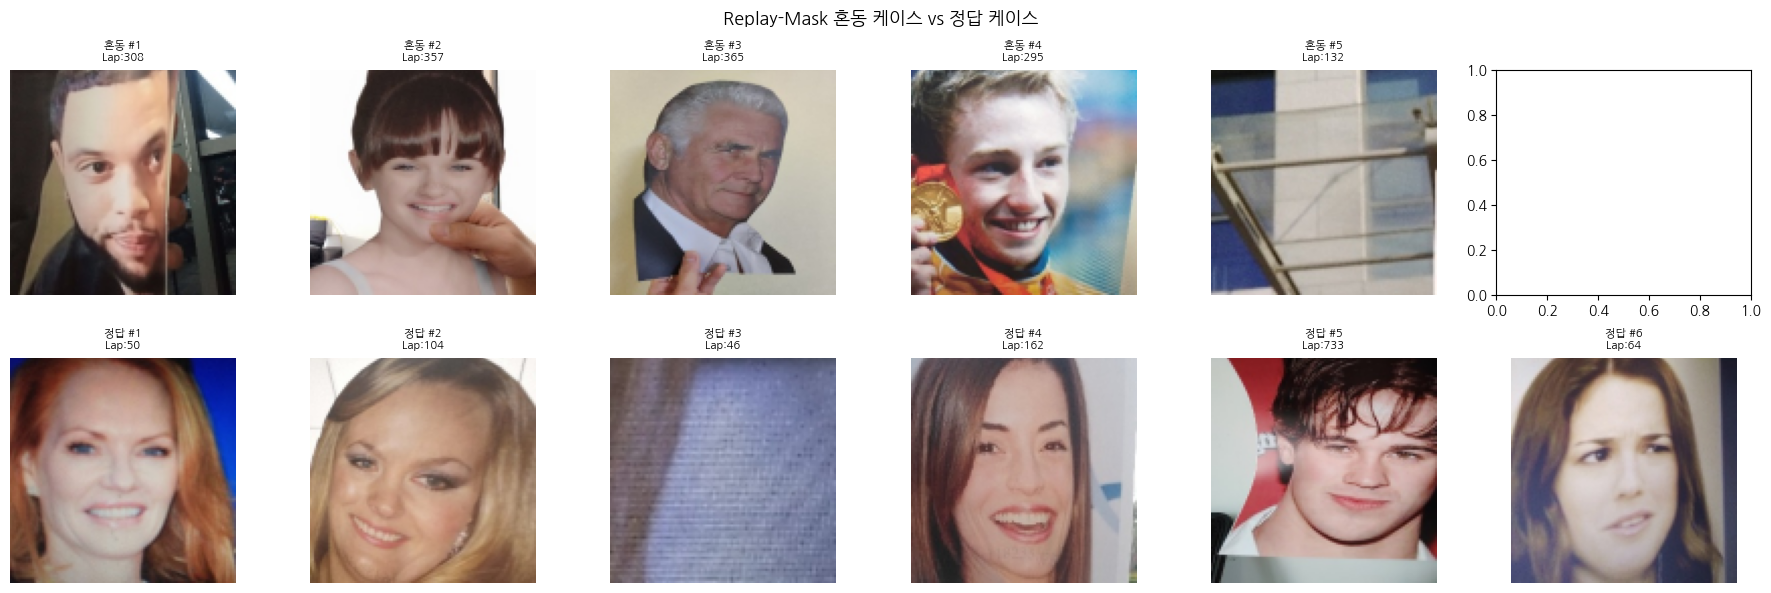

✅ 샘플 이미지 그리드 저장


In [16]:
# Replay → Mask 혼동 케이스 이미지 vs 정상 Replay 이미지 나란히 표시
if 'spoof_pred' in df.columns and 'confused' in replay_df.columns:
    confused_samples = confused_group.head(6)
    correct_samples  = correct_group.head(6)

    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for i, (_, row) in enumerate(confused_samples.iterrows()):
        img = cv2.imread(row['path'])
        if img is not None:
            img = cv2.cvtColor(cv2.resize(img, (112, 112)), cv2.COLOR_BGR2RGB)
            axes[0, i].imshow(img)
            axes[0, i].set_title(f'혼동 #{i+1}\nLap:{row["laplacian"]:.0f}', fontsize=8)
        axes[0, i].axis('off')

    for i, (_, row) in enumerate(correct_samples.iterrows()):
        img = cv2.imread(row['path'])
        if img is not None:
            img = cv2.cvtColor(cv2.resize(img, (112, 112)), cv2.COLOR_BGR2RGB)
            axes[1, i].imshow(img)
            axes[1, i].set_title(f'정답 #{i+1}\nLap:{row["laplacian"]:.0f}', fontsize=8)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('혼동 (→Mask)', fontsize=10)
    axes[1, 0].set_ylabel('정답 (Replay)', fontsize=10)
    fig.suptitle('Replay-Mask 혼동 케이스 vs 정답 케이스', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/replay_mask_sample_grid.png', dpi=150)
    plt.show()
    print('✅ 샘플 이미지 그리드 저장')

## Cell 9. Illumination 조건별 FAR

In [19]:
# Illumination이 어노테이션에 있는 샘플만 분석
df_illum = df[df['illumination'] >= 0].copy()
print(f'Illumination 어노테이션 있는 샘플: {len(df_illum)}장')
print(df_illum.groupby('illumination')['category'].value_counts().unstack(fill_value=0))

illum_results = []
for illum_id, illum_name in ILLUM_MAP.items():
    sub_all   = df_illum[df_illum['illumination'] == illum_id]
    if len(sub_all) == 0:
        continue
    sub_spoof = sub_all[sub_all['binary_label'] == 1]
    sub_live  = sub_all[sub_all['binary_label'] == 0]

    FAR = (sub_spoof['binary_pred'] == 0).sum() / len(sub_spoof) if len(sub_spoof) > 0 else None
    FRR = (sub_live['binary_pred']  == 1).sum() / len(sub_live)  if len(sub_live)  > 0 else None
    ACC = (sub_all['binary_pred'] == sub_all['binary_label']).mean()

    illum_results.append({
        'Illumination':  illum_name,
        'N':             len(sub_all),
        'FAR (%)':       f'{FAR*100:.2f}%' if FAR is not None else 'N/A',
        'FRR (%)':       f'{FRR*100:.2f}%' if FRR is not None else 'N/A',
        'Accuracy (%)':  f'{ACC*100:.2f}%'
    })

illum_df = pd.DataFrame(illum_results)
print('\n조명 조건별 FAR/FRR')
print(illum_df.to_string(index=False))

illum_df.to_csv(f'{REPORT_DIR}/far_by_illumination.csv', index=False)
print(f'\n✅ 조명별 FAR 저장')

Illumination 어노테이션 있는 샘플: 300장
category      live  mask  print  replay
illumination                           
0               75     0      0       0
1                0    42     39      46
2                0    21     17      19
3                0     7      9       8
4                0     5     10       2

조명 조건별 FAR/FRR
   Illumination   N FAR (%) FRR (%) Accuracy (%)
  Indoor-normal  75     N/A   0.00%      100.00%
  Indoor-strong 127   0.00%     N/A      100.00%
 Outdoor-normal  57   0.00%     N/A      100.00%
 Outdoor-strong  24   0.00%     N/A      100.00%
Outdoor-extreme  17   5.88%     N/A       94.12%

✅ 조명별 FAR 저장


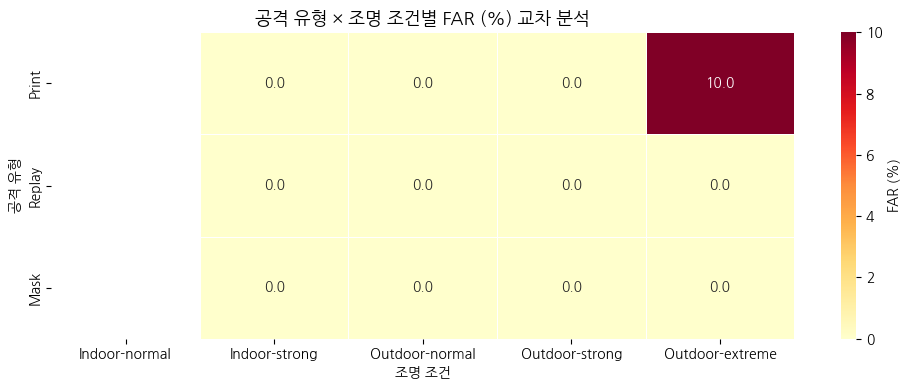

✅ 교차 히트맵 저장


In [20]:
# 공격 유형 × 조명 교차 FAR 히트맵
attack_cats = ['print', 'replay', 'mask']

cross_data = np.full((len(attack_cats), len(ILLUM_MAP)), np.nan)
for i, cat in enumerate(attack_cats):
    for j, illum_id in enumerate(ILLUM_MAP.keys()):
        sub = df_illum[(df_illum['category'] == cat) & (df_illum['illumination'] == illum_id)]
        if len(sub) > 0:
            far = (sub['binary_pred'] == 0).sum() / len(sub)
            cross_data[i, j] = far * 100

cross_df = pd.DataFrame(cross_data,
                        index=[c.capitalize() for c in attack_cats],
                        columns=list(ILLUM_MAP.values()))

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cross_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'FAR (%)'})
ax.set_title('공격 유형 × 조명 조건별 FAR (%) 교차 분석', fontsize=13)
ax.set_xlabel('조명 조건')
ax.set_ylabel('공격 유형')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/far_cross_heatmap.png', dpi=150)
plt.show()
print('✅ 교차 히트맵 저장')

## Cell 10. 최종 요약 리포트 저장

In [21]:
import json as json_lib

summary = {
    'binary_accuracy':  float(ACC_total),
    'roc_auc':          float(AUC_total),
    'FAR_total':        float(FAR_total),
    'FRR_total':        float(FRR_total),
    'FAR_by_attack':    {
        r['Attack Type']: r['FAR (%)'] for r in far_results
    },
    'targets': {
        'print_far':  '< 5%',
        'replay_far': '< 10%',
        'mask_far':   '< 8%',
        'frr':        '< 15%'
    }
}

with open(f'{REPORT_DIR}/phase4c_summary.json', 'w', encoding='utf-8') as f:
    json_lib.dump(summary, f, ensure_ascii=False, indent=2)

print('='*50)
print('  Phase 4-C FAR 분석 완료')
print('='*50)
print(f'  Binary Accuracy  : {ACC_total*100:.2f}%')
print(f'  ROC-AUC          : {AUC_total:.4f}')
print(f'  FAR (전체 Spoof) : {FAR_total*100:.2f}%')
print(f'  FRR (Live)       : {FRR_total*100:.2f}%')
print()
for r in far_results:
    print(f"  {r['Attack Type']:12s} FAR: {r['FAR (%)']:8s} (목표 {r['Target FAR']}) {r['Pass']}")
print()
print('저장 파일:')
print(f'  {REPORT_DIR}/roc_curve.png')
print(f'  {REPORT_DIR}/far_by_attack.png')
print(f'  {REPORT_DIR}/far_by_attack.csv')
print(f'  {REPORT_DIR}/spoof_confusion_matrix.png')
print(f'  {REPORT_DIR}/replay_mask_confusion_pixel.png')
print(f'  {REPORT_DIR}/replay_mask_sample_grid.png')
print(f'  {REPORT_DIR}/far_cross_heatmap.png')
print(f'  {REPORT_DIR}/far_by_illumination.csv')
print(f'  {REPORT_DIR}/phase4c_summary.json')

  Phase 4-C FAR 분석 완료
  Binary Accuracy  : 99.67%
  ROC-AUC          : 1.0000
  FAR (전체 Spoof) : 0.44%
  FRR (Live)       : 0.00%

  Print        FAR: 1.33%    (목표 < 5%) ✅
  Replay       FAR: 0.00%    (목표 < 10%) ✅
  Mask         FAR: 0.00%    (목표 < 8%) ✅
  Live (FRR)   FAR: 0.00%    (목표 < 15%) ✅

저장 파일:
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/roc_curve.png
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/far_by_attack.png
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/far_by_attack.csv
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/spoof_confusion_matrix.png
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/replay_mask_confusion_pixel.png
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/replay_mask_sample_grid.png
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/far_cross_heatmap.png
  /content/drive/MyDrive/face-anti-spoofing/reports/phase4/far_by_illumination.csv
  /content/drive/MyDrive/face-anti-spoof